# İleri Görüntü İşleme

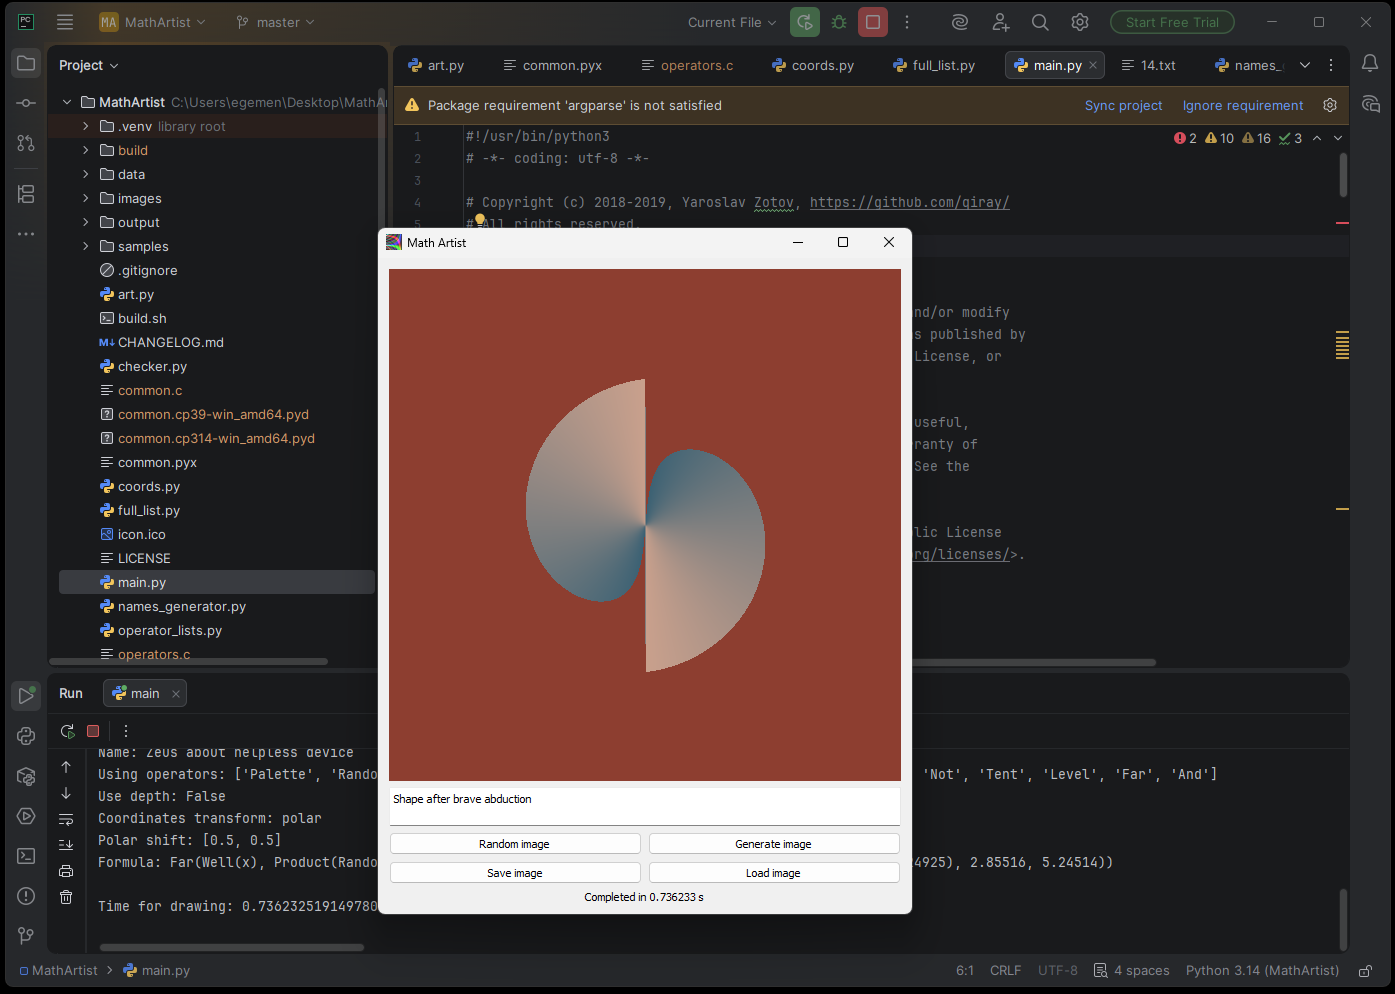

# Installation

In [24]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [25]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## Import

In [26]:
import math
import numpy as np
import cv2

## Functions

In [27]:
def well(x: float) -> float:
    result = 1 - 2 / ((1 + x * x) ** 8)
    return 1 if result < -1 else result

In [28]:
def float_color_to_int(c: float) -> int:
    return max(0, min(255, int(128 * (c + 1))))

In [29]:
def int_rgb(r: float, g: float, b: float):
    return (
        float_color_to_int(r),
        float_color_to_int(g),
        float_color_to_int(b),
        255,
    )

In [30]:
def polar(x: int, y: int, size: int, polar_shift):
    x = x - polar_shift[0] * size
    y = y - polar_shift[1] * size
    u = math.sqrt(x * x + y * y) / size
    v = 0 if x == 0 else math.atan(y / x) * 2 / math.pi
    return u, v

In [31]:
def dist(c1, c2):
    return math.sqrt(
        (c1[0] - c2[0]) ** 2 +
        (c1[1] - c2[1]) ** 2 +
        (c1[2] - c2[2]) ** 2
    )

## Image Generation

In [32]:
def render_mathartist_equivalent(size=512, polar_shift=(0.5, 0.5)):
    img = np.zeros((size, size, 4), dtype=np.uint8)

    rand1 = (0.574928, 0.255763, 0.100623)
    rand2 = (0.03488, 0.156455, 0.524925)
    phase = 2.85516
    freq = 5.24514

    c2 = (
        math.sin(phase + freq * rand2[0]),
        math.sin(phase + freq * rand2[1]),
        math.sin(phase + freq * rand2[2]),
    )

    for py in range(size):
        for px in range(size):
            u, v = polar(px, py, size, polar_shift)

            target_value = well(u)
            target = (target_value, target_value, target_value)

            c1 = (
                rand1[0] * v,
                rand1[1] * v,
                rand1[2] * v,
            )

            color = c1 if dist(c1, target) > dist(c2, target) else c2
            img[py, px] = int_rgb(*color)

    return img

In [33]:
from matplotlib import pyplot as plt

In [36]:
img_rgba = render_mathartist_equivalent(512, (0.5, 0.5))

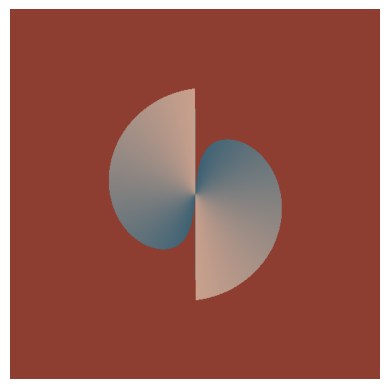

In [37]:
plt.imshow(img_rgba)
plt.axis("off")
plt.show()

## Görseli Üreten Matematiksel Formül

Bu görsel, her piksel için önce kutupsal benzeri koordinat dönüşümü uygulanarak, ardından aşağıdaki renk seçme kuralı ile üretilir.

1. Koordinat dönüşümü

Piksel koordinatı $(p_x, p_y)$ ve görüntü boyutu $N$ olsun.

Polar shift:
$$
(s_x, s_y) = (0.5, 0.5)
$$

Kaydırılmış koordinatlar:
$$
x' = p_x - s_x N
$$
$$
y' = p_y - s_y N
$$

Dönüştürülmüş koordinatlar:
$$
u = \frac{\sqrt{{x'}^2 + {y'}^2}}{N}
$$
$$
v =
\begin{cases}
0, & x' = 0 \\
\frac{2}{\pi}\arctan\left(\frac{y'}{x'}\right), & x' \neq 0
\end{cases}
$$

2. Well fonksiyonu

$$
\operatorname{well}(t) = 1 - \frac{2}{(1+t^2)^8}
$$

3. Hedef renk

$$
T(u) = \left(\operatorname{well}(u), \operatorname{well}(u), \operatorname{well}(u)\right)
$$

4. Birinci aday renk

$$
C_1(v) = \left(0.574928\,v,\;0.255763\,v,\;0.100623\,v\right)
$$

5. İkinci aday renk

$$
C_2 =
\left(
\sin(2.85516 + 5.24514 \cdot 0.03488),\;
\sin(2.85516 + 5.24514 \cdot 0.156455),\;
\sin(2.85516 + 5.24514 \cdot 0.524925)
\right)
$$

Yani $C_2$ sabit bir renktir.

6. Uzaklık fonksiyonu

İki renk arasındaki Öklid uzaklığı:
$$
d(A,B)=\sqrt{(A_r-B_r)^2+(A_g-B_g)^2+(A_b-B_b)^2}
$$

7. Piksel rengi seçimi

Her piksel için renk şu şekilde seçilir:
$$
C(u,v)=
\begin{cases}
C_1(v), & d(C_1(v), T(u)) > d(C_2, T(u)) \\
C_2, & \text{aksi halde}
\end{cases}
$$

8. Renklerin 8-bit aralığına dönüştürülmesi

Her kanal $c \in [-1,1]$ için:
$$
I(c) = \min\left(255,\max\left(0,\left\lfloor 128(c+1)\right\rfloor\right)\right)
$$

Son piksel:
$$
(R,G,B,A) = \left(I(C_r), I(C_g), I(C_b), 255\right)
$$

Görsel, her piksel için uygulanan şu parçalı renk fonksiyonu ile üretilmektedir:

$$
u = \frac{\sqrt{(p_x-0.5N)^2 + (p_y-0.5N)^2}}{N}
$$

$$
v =
\begin{cases}
0, & p_x-0.5N = 0 \\
\frac{2}{\pi}\arctan\left(\frac{p_y-0.5N}{p_x-0.5N}\right), & \text{aksi halde}
\end{cases}
$$

$$
\operatorname{well}(u)=1-\frac{2}{(1+u^2)^8}
$$

$$
T(u)=\left(\operatorname{well}(u),\operatorname{well}(u),\operatorname{well}(u)\right)
$$

$$
C_1(v)=\left(0.574928v,\;0.255763v,\;0.100623v\right)
$$

$$
C_2=\left(
\sin(2.85516+5.24514\cdot0.03488),\;
\sin(2.85516+5.24514\cdot0.156455),\;
\sin(2.85516+5.24514\cdot0.524925)
\right)
$$

$$
C(u,v)=
\begin{cases}
C_1(v), & \|C_1(v)-T(u)\| > \|C_2-T(u)\| \\
C_2, & \text{aksi halde}
\end{cases}
$$